#         ------> Makemore from scratch part 2 <------
    -> First version take as context only 1 characters, we upgrade with a version that that as context a 3 characters to predict the next character        

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline


In [ ]:
words = open("data/names.txt", "r").read().splitlines()
print(len(words))
print(words[:10])

32033
<class 'list'>
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']


In [33]:
# vocabulary of characters and mapping to integers and vice versa
chars = sorted(list(set("".join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)


{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [91]:
#building the dataset
block_size = 3                      #context length: how many characters do we take to predict the next one?
X, Y = [], []

for w in words[:5]:
    print(w)
    context = [0] * block_size      #padded context of 0 tokens [0, 0, 0]
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '---->', itos[ix])
        context = context[1:] + [ix]        #crop and append
        
X = torch.tensor(X)                         #torch.Size([5, 3])
Y = torch.tensor(Y)                         #torch.Size([5])

emma
... ----> e
..e ----> m
.em ----> m
emm ----> a
mma ----> .
olivia
... ----> o
..o ----> l
.ol ----> i
oli ----> v
liv ----> i
ivi ----> a
via ----> .
ava
... ----> a
..a ----> v
.av ----> a
ava ----> .
isabella
... ----> i
..i ----> s
.is ----> a
isa ----> b
sab ----> e
abe ----> l
bel ----> l
ell ----> a
lla ----> .
sophia
... ----> s
..s ----> o
.so ----> p
sop ----> h
oph ----> i
phi ----> a
hia ----> .


In [92]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [89]:
C = torch.randn((27,2))         #our weight matrix with 27 rows for each character, and each character being represented in 2 dims
print(C[5])
C[5][0]


tensor([-0.3295,  1.6805])


tensor(-0.3295)

------
### Embedding of an integer number = C[integer] row

#### Embedding of an integer = 1. the integer indexing into a lookup table C
    -> encoding integers into one hot and feed them to the NN, and thirst first layer basically embeds them

In [ ]:
F.one_hot(torch.tensor(5), num_classes = 27).float() @ C       #tensor with zeros and 1 on 5th position
#since we multiply 1 vector with zeros by a matrix(27,2) the result will be only the element 1(on th 5th position) multiplied by the C[5]-the 5th row of the matrix.
#the other elements will be 0
# 0 * C[0][0] = 0,
# 0 * C[1][0] = 0,
# ...
# 1 * C[5][0] = C[5][0])  =>  -0.3295
# ...
# 1 * C[5[1]] = C[5][1]   =>   1.6805

tensor([-0.3295,  1.6805])

------
### Embedding a single integer like 5 is easy, ask pytorch to retrieve the row index 5 - C[5]
    -> How do we simultaneously embbed all of the [32,3] = 96 indexes stored in the X ?
    -> C[X] ->(32, 3, 2) -> 96 rows(of indexes) of 2 columns(embeddings dimensions)
    -> batch, sequence, embedding dimensions

In [123]:
X.shape                 #torch.Size([32, 3])
C.shape                 #torch.Size([27, 2])   - Embedding table for each index of the character
emb = C[X]
emb.shape              #torch.Size([32, 3, 2])

torch.Size([32, 3, 2])

### *----->  I CAN SEARCH IN EMBEEDING LOOKUP TABLE WITH A SINGLE INDEX OR WITH A LIST OF INDICES. <-----*
    -> Searching in embedding lookup table with a list of indices result an array of embeddings.

In [124]:
X[0]    #->tensor([0, 0, 0]) = '. . .'
C[0]    #->tensor([0.1304, 0.4297]) = embedding for '.' character

C[X[0]] #->tensor([0.1304, 0.4297]),
        #         [0.1304, 0.4297],
        #         [0.1304, 0.4297]])
print(C[X[0][0]] == C[0])       #tensor([True, True])
#embeddings of '.' character from embedings lookup table(C) is the same as the first element of the first row of X (X = our input data)

tensor([True, True])


In [128]:
#ANOTHER EXAMPLE    -   'emm'

X[3]            #tensor([ 5, 13, 13])   5->'e', 13->'m', 13->'m'
C[5]            #tensor([-0.3295,  1.6805])   - Embedding for 'e'
C[13]           #tensor([ 0.7598, -0.9262])   - Embedding for 'm'

C[X[3]]         #tensor([[-0.3295,  1.6805],
                #        [ 0.7598, -0.9262],
                #        [ 0.7598, -0.9262]])

tensor([[-0.3295,  1.6805],
        [ 0.7598, -0.9262],
        [ 0.7598, -0.9262]])

## Construct the hidden layer
    -> this layer will get as input our 3 integers and their embeddings

In [ ]:
emb = C[X]
emb.shape                   #torch.Size([32, 3, 2])
W1 = torch.randn(6,100)     #inputs = 6  --->   3 * 2.  --->  3-integers as context, each has 2 dimensions
                            #neurons = 100 as example
b1 = torch.randn(100)

In [130]:
emb @ W1 + b1

RuntimeError: mat1 and mat2 shapes cannot be multiplied (96x2 and 6x100)

------
#### We want to concatenate all the 3 integers embeedings for each input smaple
 #torch.Size([32, 3, 2]) -> take the [3,2] and squash them to 6, concatenate them orizontally(dimesion = 1)

In [ ]:
emb[:, 0, :].shape      #first integer embeddings of each input. e.g for '.em' it takes only the embeddings for '.'. It does the same for each pair of the 32 pairs
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape          #NOT GENERALIZED

# A MORE GENERELIZE WAY
torch.cat(torch.unbind(emb, 1), 1).shape                                #DOESNT MATTER IF BLOCK_SIZE = 3, 10 or 100, will take everytime the block_size dimension
# .cat = INEFFICIENT because it creates a whole new tensor in memory

torch.Size([32, 6])

In [ ]:
a = torch.arange(18)                #torch.Size([18])
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

### .view can rearrage a fixed tensor vector into a specific tensor size (arguments must be devided by tensor size. 18 = 9*2.   18 = 3 * 3 * 2)
    -> all because of the way that pytorch stores tensors in memory: row-major order
    -> .views = EFFICIENT because it doesnt create new memory, only shape metadata changes. Manipulate the shape of existing memory


In [167]:
a.storage()                           #vector 1d of tensor representation in memory
a.view(3,3,2)
emb.view(32, 6) == torch.cat(torch.unbind(emb, 1), 1)   #True

tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, T

In [171]:
h = emb.view(emb.shape[0], 6) @ W1 + b1         # equivalent
h = emb.view(-1, 6) @ W1 + b1                   # equivalent
# -1 tells pytorch to automatically deduce it from other dimensions
#e.g emb = [32, 3, 2] -> 32*2*3 = 192.
# if 6 is a fixed dimension => 192 / 6 = 32 => '-1' will give the shape: emb.shape = [32, 6]

--------
## *[32, 100] + [100] = BROADCASTING* 
##### WEIGHTS([32, 100]) + BIAS([100])
    -> 1 STEP: right alignment
    -> 32,  100
    ->      100

    -> pytorch will automatically add dim=1 at left
    -> 32,  100
    -> 1,   100 

    -> 2 STEP: dimension 1 is BROADCASTED to 32 (BIAS vector is copied 32 times)
    -> 32,  100
    -> 32,  100     = this rows is copied 32 times
    

In [ ]:
no_bias = emb.view(-1, 6) @ W1
no_bias.shape                                   #torch.Size([32, 100])
b1.shape                                        #torch.Size([100])      

torch.Size([100])

In [ ]:
W1 = torch.randn(6,100)                         #6 inputs - 100 neurons
b1 = torch.randn(100)                           #1 bias for each neuron
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
h.shape                                         #torch.Size([32, 100])

torch.Size([32, 100])

In [179]:
W2 = torch.randn(100, 27)                       #100 neuron(previous layer) - 27 neurons for 27 characters that comes next
b2 = torch.randn(27)

In [180]:
logits = h @ W2 + b2
logits.shape

torch.Size([32, 27])

In [197]:
counts = logits.exp()
prob = counts / counts.sum(dim = 1, keepdim = True)
prob.shape

torch.Size([32, 27])

-----
## Get the actual (random) probabilities of the target character
#### For each 32 rows we have 27 probabilities to be the next char
#### For each 32 rows get the actual probabilities for the next character

In [198]:
Y.shape                         #torch.Size([32])
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [ ]:
torch.arange(32)                #array of 32 values(from 0-31)
prob[0]                         #firs row of probabilities of each characters(27)
print(Y[0])                     #5 - for the first row I want the probabilities at index 5

prob[torch.arange(32), Y]       #1. prob[0][5].   2. prob[1][13].   3. prob[2][13]

tensor(5)


tensor([9.9357e-11, 6.4601e-11, 7.7586e-12, 6.8357e-16, 3.8828e-09, 6.4496e-11,
        1.2756e-04, 5.3472e-05, 6.7843e-08, 7.7453e-04, 7.2417e-07, 3.8403e-05,
        4.4104e-13, 1.3700e-06, 9.6986e-09, 2.2117e-06, 4.0525e-02, 6.8095e-03,
        7.1096e-07, 2.9291e-07, 1.9754e-03, 2.9236e-03, 4.8127e-11, 2.5238e-17,
        7.2007e-09, 1.1758e-02, 1.5977e-10, 4.0406e-12, 2.6992e-12, 4.0886e-04,
        2.3321e-07, 5.1334e-07])

In [222]:
loss = -prob[torch.arange(32), Y].log().mean()
loss

tensor(16.8012)

-----
### ------->    SUMMARIZED      <-------

In [225]:
#32 inputs with 3 characters each to predict the next 1 character for each input
X.shape, Y.shape #dataset

(torch.Size([32, 3]), torch.Size([32]))

In [363]:
g = torch.Generator().manual_seed(2147483647)                   # for reproducibility
C = torch.randn((27, 2), generator = g)                         # embedding table - 2 values for each character (27 characters)
W1 = torch.randn((6, 100), generator = g)
b1 = torch.randn((100), generator = g)
w2 = torch.randn((100, 27), generator = g)
b2 = torch.randn((27), generator = g)
parameters = [C, W1, b1, W2, b2]                                #list with all parameters

In [364]:
sum(p.nelement() for p in parameters)                           #total number of parameters

3481

In [365]:
for p in parameters:
    p.requires_grad = True

In [251]:
for _ in range(1000):
    #forward pass
    emb = C[X]                                                      #(32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)                       #(32, 100)
    logits = h @ W2 + b2                                            #(32, 27)
    #counts = logits.exp()
    #prob = counts / counts.sum(dim = 1, keepdim = True)
    #loss = - prob[torch.arange(32), Y].log().mean()
    #           -> this 3 operations are INEFFICIENT because pytprch will create whole new tensors in memmory

    #equivalent (but EFFICIENT)

    loss = F.cross_entropy(logits, Y)              #FORWARD & BACKWARD more EFFICIENT
    
    #backward pass 
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    for p in parameters:
        p.data += -0.1 * p.grad

print(loss.item())

0.2529733180999756


## Above its only for 32 examples (taken from only first 5 words)
--------
## Full Dataset

In [361]:
g = torch.Generator().manual_seed(2147483647)                   # for reproducibility
block_size = 3
X, Y = [], []

for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)               
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [299]:
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [404]:
for _ in range(10):
    #forward pass
    emb = C[X]                                      #torch.Size([228146, 3, 2])
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)       #torch.Size([228146, 100])
    logits = h @ W2 + b2                            #torch.Size([228146, 27])
    loss = F.cross_entropy(logits, Y)
    print(loss.item())
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    #update
    for p in parameters:
        p.data += -0.1 * p.grad

6.980088233947754
6.329420566558838
5.933177471160889
5.638986587524414
5.402029991149902
5.212016582489014
5.0543084144592285
4.917889595031738
4.797626495361328
4.690718650817871


#### For 228146 example it takes time to forward and backward each example
    -> in practice we perform forward and backward in mini batches
    -> randomly select some random parts of data and that a mini-batch -> forward & backward for that mini-batch -> iterate on those mini batches

In [356]:
#Create a vector of size 32 with values between [0-228146]. X.shape[0] = 228146
#random values for mini batches selection
torch.randint(0, X.shape[0], (32,))

tensor([ 83318,  52076,   4382,  40095, 209222, 172201, 218527, 192315,  45738,
        204719,  11453, 200230,  14512,  96130, 152650,  75736, 183571,  44784,
        212408, 164107, 204353,  39905, 225130, 114603, 213325,  73979,  73985,
         75230, 175075,  66580,  55409, 163605])

In [579]:
g = torch.Generator().manual_seed(2147483647)                   # for reproducibility
C = torch.randn((27, 2), generator = g)                         # embedding table - 2 values for each character (27 characters)
W1 = torch.randn((6, 100), generator = g)
b1 = torch.randn((100), generator = g)
W2 = torch.randn((100, 27), generator = g)
b2 = torch.randn((27), generator = g)
parameters = [C, W1, b1, W2, b2]                                #list with all parameters
for p in parameters:
    p.requires_grad = True

In [464]:
for _ in range(10):
    
    #minibatches construct
    ix = torch.randint(0, X.shape[0], (32,))
    #forward pass
    emb = C[X[ix]]                                  #torch.Size([32, 3, 2])     -> we select only the 32 random(shuffled) rows for minibatches
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)       #(32, 100)
    logits = h @ W2 + b2                            #(32, 27)
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())                              #loss for that mini batch

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    for p in parameters:
        p.data += -0.1 * p.grad

2.9787824153900146
3.472871780395508
2.6830711364746094
2.769831418991089
2.8724794387817383
2.619426727294922
2.9524898529052734
2.737644672393799
2.928269624710083
2.13342547416687


In [424]:
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
loss

tensor(2.6186, grad_fn=<NllLossBackward0>)

----
## *How do you determine the learning rate? Step size*
### How we get confidence that we found a fairly good lr

In [580]:
#step between this linearly
lr = torch.linspace(0.001, 0, 1000)             #1000 numbers between [0.001, 0]

#step between this logaritmic -  in PRACTICE
lre = torch.linspace(-3, 0, 1000)               #10^-3 = 0.001.    10^0 = 1
lrs = 10**lre

In [581]:
lri = []
lossi = []

for i in range(1000):

    ix = torch.randint(0, X.shape[0], (32,))
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    lri.append(lre[i])
    lossi.append(loss.item())

21.049726486206055
19.25774383544922
16.14641571044922
20.44000244140625
19.893495559692383
22.26313018798828
20.373043060302734
20.0122127532959
16.506942749023438
19.317903518676758
19.515043258666992
18.060710906982422
16.894142150878906
20.287357330322266
21.293928146362305
18.14948081970215
21.06182289123535
22.508657455444336
19.131988525390625
18.171667098999023
20.509977340698242
18.929908752441406
18.163244247436523
19.641311645507812
18.38445281982422
18.955839157104492
18.524728775024414
20.816482543945312
19.073312759399414
18.28468894958496
19.031362533569336
17.86900520324707
18.9351863861084
18.925600051879883
17.806947708129883
20.319011688232422
18.129112243652344
18.53215980529785
17.664379119873047
19.094945907592773
18.165010452270508
20.665794372558594
17.544902801513672
17.56206703186035
19.600570678710938
19.5546932220459
17.49872398376465
15.835860252380371
18.148685455322266
17.458101272583008
15.74537467956543
16.524925231933594
16.59951400756836
17.8545207977

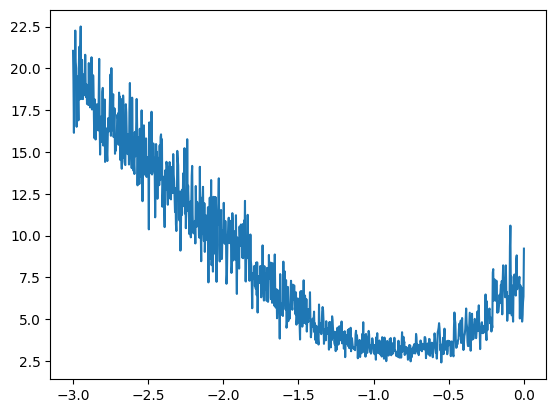

In [582]:
plt.plot(lri, lossi)

## A good lr is somewhere between -1.0 and -0.5

In [583]:
g = torch.Generator().manual_seed(2147483647)                   # for reproducibility

C = torch.randn((27, 2), generator = g)                         # embedding table - 2 values for each character (27 characters)
W1 = torch.randn((6, 100), generator = g)
b1 = torch.randn((100), generator = g)
W2 = torch.randn((100, 27), generator = g)
b2 = torch.randn((27), generator = g)
parameters = [C, W1, b1, W2, b2]                                #list with all parameters
for p in parameters:
    p.requires_grad = True

In [584]:
for i in range(1000):

    ix = torch.randint(0, X.shape[0], (32,))
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())

    for p in parameters:
        p.grad = None
    loss.backward()

    for p in parameters:
        p.data += -0.01 * p.grad


19.28805160522461
20.324748992919922
20.776283264160156
17.744508743286133
19.468036651611328
15.799391746520996
17.230730056762695
17.441640853881836
17.691631317138672
16.44515609741211
16.95677375793457
16.9252986907959
16.238431930541992
17.111120223999023
18.353195190429688
14.348666191101074
13.998822212219238
17.42576789855957
15.407672882080078
15.008474349975586
16.80147933959961
15.990246772766113
13.171858787536621
13.62346076965332
16.238651275634766
16.734737396240234
12.527151107788086
14.93192195892334
12.657964706420898
14.67198371887207
15.272327423095703
14.596476554870605
15.50632381439209
14.369964599609375
14.912446022033691
11.387722969055176
16.281253814697266
15.564659118652344
16.84579086303711
15.757196426391602
11.50033187866211
15.105659484863281
14.899221420288086
15.388775825500488
14.063311576843262
14.553791046142578
14.678389549255371
14.309616088867188
12.784322738647461
14.308914184570312
13.577890396118164
14.91828727722168
14.646977424621582
12.6338

In [585]:
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

logits = h @ W2 + b2
loss = F.cross_entropy(h, Y)
print(loss.item())

4.928823471069336


------
### Weight decay
    -> in the late stages of training -> 10x lower the learning rate

-----
## ------> *DATASET SPLIT* <------
    -> training, validation, test split
    -> training = train the paramters
    -> validation = train the hyperparameters
    -> test = evaluate the performance of the model at the end

In [586]:
#build the dataset

def build_dataset(words):
    block_size = 3              #context length: how many characters do we take as input to predict the next character
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for char in w + '.' : #appends the . at the end of each word
            ix = stoi[char]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y


import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])             #80% of the data
Xval, Yval = build_dataset(words[n1:n2])         #10% of the data
Xte, Yte = build_dataset(words[n2:])             #10% of the data
            


torch.Size([182441, 3]) torch.Size([182441])
torch.Size([22902, 3]) torch.Size([22902])
torch.Size([22803, 3]) torch.Size([22803])


In [599]:
g = torch.Generator().manual_seed(2147483647)                   # for reproducibility
C = torch.randn((27, 2), generator = g)                         # embedding table - 2 values for each character (27 characters)
W1 = torch.randn((6, 300), generator = g)
b1 = torch.randn((300), generator = g)
W2 = torch.randn((300, 27), generator = g)
b2 = torch.randn((27), generator = g)
parameters = [C, W1, b1, W2, b2]                                #list with all parameters
for p in parameters:
    p.requires_grad = True

In [600]:
sum(p.nelement() for p in parameters)                           #total number of parameters

10281

In [596]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [629]:
lri = []
lossi = []
stepi = []

for i in range(30000):

    #forward pass
    ix = torch.randint(0, Xtr.shape[0], (32,))
    emb = C[Xtr[ix]]                                # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1)       # (32, 300)
    logits = h @ W2 + b2                            # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    lr = 0.05
    for p in parameters:
        p.data += -lr * p.grad
    
    #track stats
    #lri.append(i)
    stepi.append(i)
    lossi.append(loss.item())

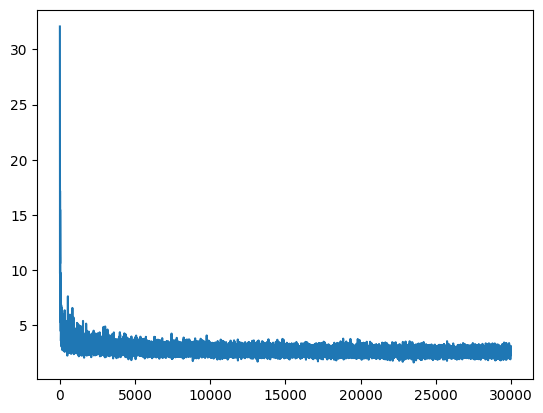

In [602]:
plt.plot(stepi, lossi)

In [590]:
print(loss.item())

2.4796576499938965


In [630]:
emb = C[Xval]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yval)
loss


tensor(2.3132, grad_fn=<NllLossBackward0>)

In [627]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.2615, grad_fn=<NllLossBackward0>)

## *Underfitting* = Training and Validation loss are both realatively equal
    -> Tipicaly means that our network is very tiny
        -> Scale up the size of the network

----
Try to understand what the bottleneck may be.

    -> since we made our hidden layer much bigger (100->300) and the loss is not suffienctly decreseaing

    -> it could be the fact that we store our characters in 2 dimensions(emb dim = 2)

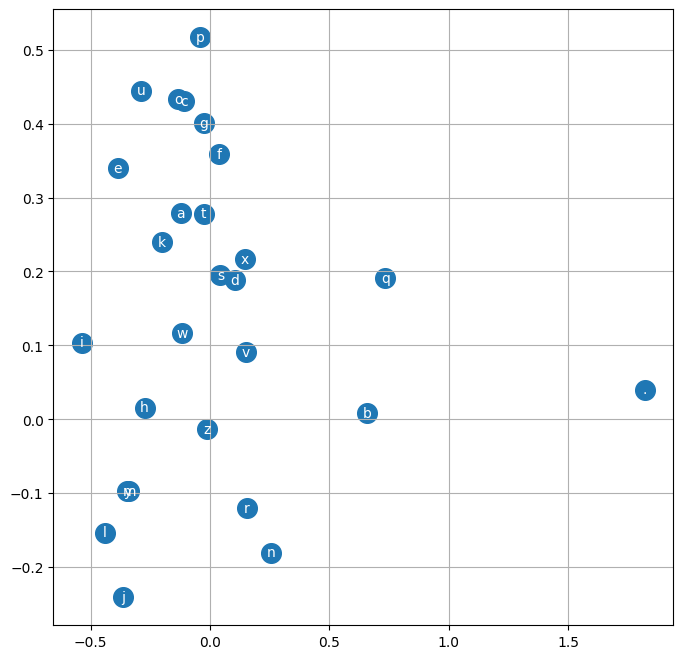

In [657]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color="white")
plt.grid('minor')

Change the embedding dim to 10

In [723]:
g = torch.Generator().manual_seed(2147483647)                   # for reproducibility
C = torch.randn((27, 10), generator = g)                        # embedding table - 2 values for each character (27 characters)
W1 = torch.randn((30, 200), generator = g)                      # 30 = 3 * 10. 3 chars of 10 dim each
b1 = torch.randn((200), generator = g)
W2 = torch.randn((200, 27), generator = g)
b2 = torch.randn((27), generator = g)
parameters = [C, W1, b1, W2, b2]                                #list with all parameters
for p in parameters:
    p.requires_grad = True

In [724]:
sum(p.nelement() for p in parameters)

11897

In [725]:
lri = []
lossi = []
stepi = []

In [745]:
for i in range(200000):

    #forward pass
    ix = torch.randint(0, Xtr.shape[0], (32,))      #mini batch of size 32
    emb = C[Xtr[ix]]                                # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)       # (32, 300)
    logits = h @ W2 + b2                            # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    #track stats
    #lri.append(i)
    stepi.append(i)
    lossi.append(loss.log10().item())

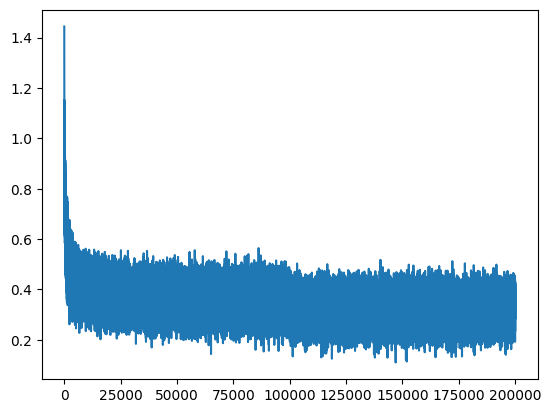

In [727]:
plt.plot(stepi, lossi)

In [746]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss.item()

2.0797293186187744

In [747]:
emb = C[Xval]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yval)
loss.item()

2.1444170475006104

----
Sampling from the new trained model

In [744]:
g = torch.Generator().manual_seed(2147483647 + 10)
for _ in range(20):
    
    out = []
    context = [0] * block_size                          #context = [0, 0, 0]
    while True:                 
        emb = C[torch.tensor([context])]                #C[[0, 0, 0]]   #3 same vectors of embeedings for the chars with index 0 ('.')
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)       #(1, 30) @ (30, 200) 
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim = 1)              #probabiliti distribution: -> exp() -> sum of each row -> devide each element of each correspondent row sum. shape(1, 27)
        ix = torch.multinomial(probs, num_samples = 1, generator = g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

carpahela.
jheri.
kimlin.
tatyannah.
saeja.
hut.
faresart.
kaeli.
nellara.
chaiir.
kaleigh.
ham.
joce.
quintis.
lilea.
jadiquwraelogiefryni.
jacee.
durat.
edde.
iia.
